# Подготовка и очистка данных для медицинского LLM-ассистента

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
import faiss

from pathlib import Path

## 1. Загрузка данных

Датасет Doctor-HealthCare-100k содержит медицинские запросы и ответы в формате `instruction / input / output`.

In [3]:
dataset_path = "../materials/Doctor-HealthCare-100k.csv"

df_raw = pd.read_csv(dataset_path)
df = df_raw.copy()

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (112156, 3)


,instruction,input,output
0,"If you are a doctor, please answer the medical...",I woke up this morning feeling the whole room ...,"Hi, Thank you for posting your query. The most..."
1,"If you are a doctor, please answer the medical...",My baby has been pooing 5-6 times a day for a ...,Hi... Thank you for consulting in Chat Doctor....
2,"If you are a doctor, please answer the medical...","Hello, My husband is taking Oxycodone due to a...","Hello, and I hope I can help you today.First, ..."
3,"If you are a doctor, please answer the medical...",lump under left nipple and stomach pain (male)...,HI. You have two different problems. The lump ...
4,"If you are a doctor, please answer the medical...",I have a 5 month old baby who is very congeste...,Thank you for using Chat Doctor. I would sugge...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112156 entries, 0 to 112155
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   instruction  112156 non-null  object
 1   input        112156 non-null  object
 2   output       112156 non-null  object
dtypes: object(3)
memory usage: 2.6+ MB


In [5]:
# и проверка строк, которые технически не NaN, но пустые
df.apply(lambda col: col.str.strip().eq("").sum())

instruction    0
input          0
output         0
dtype: int64

In [6]:
df.nunique()

instruction         1
input          112002
output         109301
dtype: int64

In [7]:
instruction = df["instruction"].iloc[0]
instruction

"If you are a doctor, please answer the medical questions based on the patient's description."

Столбец `instruction` содержит одно и то же значение во всех примерах и не несёт информации, различающей наблюдения. В дальнейшей обработке используется только пара `input → output`, поэтому `instruction` исключается из рабочей таблицы.

In [8]:
df = df.drop(columns="instruction")

## 2. Проверка информативности пользовательских запросов

Проверяется распределение длины `input` и наличие аномально коротких запросов, которые могут содержать недостаточный контекст для корректного медицинского ответа.

Длина используется только как индикатор потенциально проблемных примеров, а не как самостоятельный критерий качества.

In [9]:
df["input_words"] = df["input"].str.split().str.len()
df["input_words"].describe()

count    112156.000000
mean         81.144763
std          47.467896
min           1.000000
25%          56.000000
50%          68.000000
75%          92.000000
max        2218.000000
Name: input_words, dtype: float64

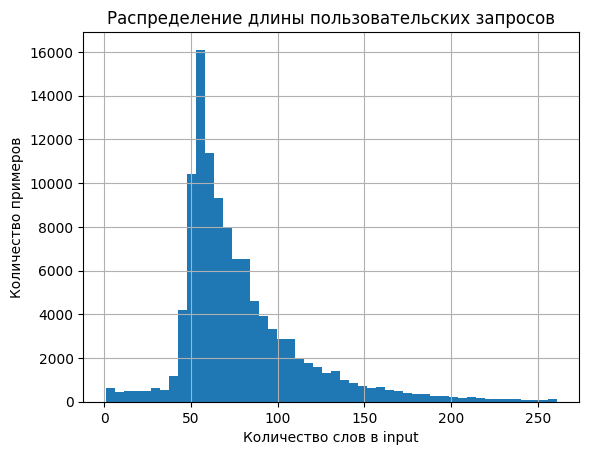

In [10]:
p99 = df["input_words"].quantile(0.99)

df.loc[
    df["input_words"] <= p99,
    "input_words"
].hist(bins=50)

plt.xlabel("Количество слов в input")
plt.ylabel("Количество примеров")
plt.title("Распределение длины пользовательских запросов")
plt.show()

Большинство пользовательских запросов содержит примерно 50–100 слов. Распределение имеет правый хвост: встречаются существенно более длинные запросы, однако они составляют небольшую долю выборки.

Отдельного внимания требуют аномально короткие `input`, поскольку часть из них может представлять собой обрывки форм, служебные поля или запросы с недостаточным контекстом для медицинского ответа.

In [11]:
for n in [1, 2, 3, 5, 10, 15]:
    count = (df["input_words"] <= n).sum()
    share = count / len(df) * 100
    print(f"≤ {n:2} слов: {count:4} ({share:.2f}%)")

≤  1 слов:  222 (0.20%)
≤  2 слов:  324 (0.29%)
≤  3 слов:  401 (0.36%)
≤  5 слов:  550 (0.49%)
≤ 10 слов:  991 (0.88%)
≤ 15 слов: 1493 (1.33%)


In [12]:
short_unique = (
    df.loc[df["input_words"] < 10, ["input", "input_words"]]
    .drop_duplicates(subset="input")
    .sort_values(["input_words", "input"])
)

print("Уникальных коротких input:", len(short_unique))
short_unique.head(15)

Уникальных коротких input: 751


,input,input_words
66175,.,1
73450,AGE,1
6515,Age,1
11773,Age-74.3,1
56206,Atrophy,1
9697,Background,1
93997,CC,1
63837,CONCLUSION,1
100236,Cardiology,1
73319,Cc,1


Короткие пользовательские запросы составляют менее 1% датасета. При ручном просмотре среди них обнаружено много неполных и служебных записей: отдельные поля анкеты (`Age`, `Gender`, `History`, `Diagnosis`), приветствия и текстовые артефакты.

Для уменьшения шума из датасета исключаются запросы короче 10 слов. Такой фильтр может удалить небольшое число валидных коротких вопросов, однако затрагивает менее 1% выборки и существенно снижает долю примеров с недостаточным контекстом.

Порог в 10 слов используется как простая эвристика для удаления большого числа явно неполных и служебных записей. При этом часть коротких вопросов может быть валидной, поэтому правило не является строгим критерием качества данных. Мы сознательно принимаем небольшую потерю корректных примеров, поскольку их доля мала относительно общего объёма датасета, а усложнение фильтрации на этом этапе не даёт существенной практической выгоды.

In [13]:
min_input_words = 10

removed_short = (df["input_words"] < min_input_words).sum()

df = df.loc[df["input_words"] >= min_input_words].copy()

print(f"Удалено коротких запросов: {removed_short}")
print(f"Осталось строк: {len(df)}")

Удалено коротких запросов: 898
Осталось строк: 111258


## 3. Проверка информативности медицинских ответов

Проверяется распределение длины `output` и наличие аномально коротких или длинных ответов, которые могут указывать на повреждённые, неполные или нетипичные примеры.

Длина используется как способ поиска кандидатов на дополнительную проверку, а не как самостоятельный критерий качества ответа.

In [14]:
df["output_words"] = df["output"].str.split().str.len()

df["output_words"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

count    111258.000000
mean        102.127128
std          41.361197
min           1.000000
25%          78.000000
50%          95.000000
75%         120.000000
90%         150.000000
95%         175.000000
99%         243.000000
max         591.000000
Name: output_words, dtype: float64

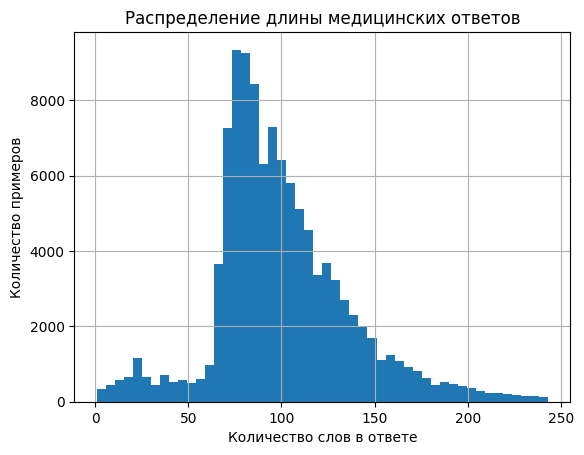

In [15]:
p99_output = df["output_words"].quantile(0.99)

df.loc[
    df["output_words"] <= p99_output,
    "output_words"
].hist(bins=50)

plt.xlabel("Количество слов в ответе")
plt.ylabel("Количество примеров")
plt.title("Распределение длины медицинских ответов")
plt.show()

In [16]:
df.nsmallest(10, "output_words")[["input", "output", "output_words"]]

,input,output,output_words
271,"Hi I am 51 female ,perimenopausal,for the last...",Hello,1
2555,Ive severe toothache in one of my molars the p...,Hello,1
4534,Ive been snorting and occasionally smoking met...,Hello,1
4925,my husband has suffered a back injury like 9 m...,Answer,1
5586,I am experiencing lack of strength and sorenes...,Answer,1
10327,SirI am using Pan Parag a tobacco product. I h...,Hello,1
13089,Hi I have a terrible pain in mouth..on touchin...,Hello,1
13999,I quit smoking recently and now a large area o...,Hello,1
14760,My wisdom teeth are growing through at the mom...,Hello,1
15051,"Hello Doctor, Hope you are doing good. My name...",Answer,1


In [17]:
for n in [1, 2, 3, 5, 10]:
    count = (df["output_words"] <= n).sum()
    share = count / len(df) * 100

    print(f"≤ {n:2} слов: {count:4} ({share:.2f}%)")

≤  1 слов:   68 (0.06%)
≤  2 слов:  214 (0.19%)
≤  3 слов:  275 (0.25%)
≤  5 слов:  337 (0.30%)
≤ 10 слов:  775 (0.70%)


In [18]:
min_output_words = 10

removed_short_outputs = (df["output_words"] < min_output_words).sum()

df = df[df["output_words"] >= min_output_words].copy()

print("Удалено коротких ответов:", removed_short_outputs)
print("Осталось строк:", len(df))

Удалено коротких ответов: 688
Осталось строк: 110570


Короткие ответы составляют менее 1% датасета. При ручном просмотре среди них обнаружено много неполных и технических записей (`Hello`, `Answer`, `Brief`, `Dear` и т. п.).

Для уменьшения шума исключены `output` короче 10 слов. Фильтр затрагивает менее 1% выборки, поэтому потеря небольшого числа потенциально валидных коротких ответов будем считать приемлемым компромиссом.

## 4. Проверка дубликатов пользовательских запросов

Сначала проверяются точные совпадения после простой нормализации регистра и пробелов.

In [19]:
df["_input_key"] = (
    df["input"]
    .str.strip()
    .str.casefold()
    .str.replace(r"\s+", " ", regex=True)
)

In [20]:
duplicate_mask = df["_input_key"].duplicated(keep=False)
duplicate_rows = df[duplicate_mask]

print("Строк в duplicate-группах:", len(duplicate_rows))
print(
    "Уникальных повторяющихся запросов:",
    duplicate_rows["_input_key"].nunique()
)

Строк в duplicate-группах: 34
Уникальных повторяющихся запросов: 17


In [21]:
duplicate_rows["_input_key"].value_counts()

_input_key
done semen analysis. trying to have a baby. help hi doctors i am 30 year old got married on april 2012 and i am trying to make wife pregnant since 6 months i know her ovluation period it 12th o 18th day from menstrual period. i have arthritis since 10 years and i m taking 25 mg diclofenac sodium t.i.d. .. even while having sex you put pillow below the buttocks and have correct in ovulation period. and my semen analysis report is vol                                                                                                                                                                                                                      2
hi all and one, i just had a tooth extraction done monday just gone. was glad to find that i dont have a dry socket but several things are worrying me                                                                                                                                                                                           

In [22]:
duplicate_summary = (
    duplicate_rows
    .groupby("_input_key")
    .agg(
        rows=("input", "size"),
        unique_outputs=("output", "nunique"),
    )
)

duplicate_summary

,rows,unique_outputs
_input_key,,
55 yr old female. i have been having pain in the upper right abdominal area under and below ribs also to the back - 4 days now. the pain is worse when i burp or hiccup (diaphragm spasms?). deep breaths also are difficult. pain sometimes radiates or refers to the collar bone area.,2,2
done semen analysis. trying to have a baby. help hi doctors i am 30 year old got married on april 2012 and i am trying to make wife pregnant since 6 months i know her ovluation period it 12th o 18th day from menstrual period. i have arthritis since 10 years and i m taking 25 mg diclofenac sodium t.i.d. .. even while having sex you put pillow below the buttocks and have correct in ovulation period. and my semen analysis report is vol,2,2
"for about 4 months now i have had a small rad spot right on my gum underneath my tooth. i do not think it has gotten any bigger, but it bleeds very easily and is worrying me because it is not going away. i do have a little gingivitis, but i brush everyday so i take pretty good care of my teeth, but i am just worried it is cancer or something. do you have any ideas?",2,2
head and chest pains i have sickle cell disease and i keep having sharp pains in my chest in my head im wondering if he has anything to do with my sickle cell.... i been having these pains for the last four or five days... when i have the pain in my chest feels like im kinda having a heart attack thats how bad pain is... what could be the problem what could be wrong,2,2
"hello, i have a possible serious medical question. i have had large lumps under my armpits for years, it has an outword appearance of small golf balls of skin. i also get pain in my breast from time to time, i have constant mucus or thick saliva in my throat. should i be worried.",2,2
"hi all and one, i just had a tooth extraction done monday just gone. was glad to find that i dont have a dry socket but several things are worrying me",2,2
"hi doctor, my platelets was 1.5million, doctors told me it is essential thrombocytosis , started with the medicine hydroxyurea, and my paltelets become 400 thousand then i got some skin rashes and doctors advised to stop the hydroxyurea and started anagralayd after fewmonths they stopped it and started imatinib i took it arround six months there is no improvement then they shifted the medicine to dasatinib150mg daily still my paltelets are 780thousand i done bcr- abl 3 times it is negative,but the doctors here they are saying i am a cml patient, now they are going to shift the medicine agin to nilotinib. i need your advise in this matter.",2,2
hi doctors. please help me im desperate for medical attention for my beloved sisterher symptoms includes,2,2
"hi, may i answer your health queries right now ? please type your query here...hi",2,2


In [23]:
duplicate_pairs = (
    duplicate_rows
    .sort_values("_input_key")
    [["_input_key", "output"]]
)

duplicate_pairs

,_input_key,output
35578,55 yr old female. i have been having pain in t...,HI. Thanks for a perfect book-picture type sym...
20815,55 yr old female. i have been having pain in t...,Welcome to Chat Doctor .1. Before treatment on...
6562,done semen analysis. trying to have a baby. he...,"Hi, According to the latest WHO criteria, your..."
98596,done semen analysis. trying to have a baby. he...,"Hello, Welcome to Chat Doctor, I am Chat Docto..."
39881,for about 4 months now i have had a small rad ...,Hello there.... There are many reasons for tha...
52449,for about 4 months now i have had a small rad ...,Thanks for using Chat Doctor. Read your query....
17077,head and chest pains i have sickle cell diseas...,Thanks for your question on Chat Doctor. I can...
108045,head and chest pains i have sickle cell diseas...,"Hi, Thanks for asking. Based on your clinical ..."
37502,"hello, i have a possible serious medical quest...",Hi.Thanks for your query. Noted your history o...
45284,"hello, i have a possible serious medical quest...","Hi, Welcome to Chat Doctor. Based on the facts..."


In [24]:
print("Удалено строк с повторяющимися запросами:", duplicate_mask.sum())

df = df.loc[~duplicate_mask].copy()

print("Осталось строк:", len(df))

Удалено строк с повторяющимися запросами: 34
Осталось строк: 110536


In [25]:
df["_input_key"].duplicated().sum()

np.int64(0)

После нормализации регистра и пробелов обнаружено 17 повторяющихся пользовательских запросов (34 строки). Для каждого одинакового `input` в датасете присутствовали разные `output`.

Поскольку таких примеров менее 0,1% выборки, все строки из конфликтующих duplicate-групп исключены, чтобы не выбирать reference answer произвольно и не допускать повторения одного запроса в дальнейших выборках.

## 5. Проверка смысловых дубликатов

Точное сравнение строк не выявляет переформулированные запросы с тем же смыслом. Такие примеры могут попасть в разные части train/dev/test и завысить итоговую оценку модели.

Для поиска кандидатов на смысловые дубликаты запросы представляются в виде embeddings и сравниваются по близости в векторном пространстве. Высокая similarity используется только для поиска подозрительных пар, а не как автоматическое правило удаления.

In [30]:
texts = [
    "I feel dizzy when I stand up.",
    "When I get out of bed, I become light-headed.",
    "What causes migraine?"
]

In [31]:
embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4627.93it/s]


In [32]:
embeddings = embedding_model.encode(
    texts,
    normalize_embeddings=True
)

embeddings.shape

(3, 384)

In [33]:
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings.astype("float32"))

In [34]:
scores, indices = index.search(
    embeddings.astype("float32"),
    k=3
)

In [37]:
for i, text in enumerate(texts):
    print("\nQUERY:", text)

    for score, j in zip(scores[i], indices[i]):
        print(round(float(score), 3), "-", texts[j])


QUERY: I feel dizzy when I stand up.
1.0 - I feel dizzy when I stand up.
0.76 - When I get out of bed, I become light-headed.
0.607 - What causes migraine?

QUERY: When I get out of bed, I become light-headed.
1.0 - When I get out of bed, I become light-headed.
0.76 - I feel dizzy when I stand up.
0.597 - What causes migraine?

QUERY: What causes migraine?
1.0 - What causes migraine?
0.607 - I feel dizzy when I stand up.
0.597 - When I get out of bed, I become light-headed.


### Строим embeddings для всего датасета

In [44]:
texts = df["input"].tolist()

In [45]:
embeddings = embedding_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype("float32")

Batches: 100%|██████████| 1728/1728 [37:43<00:00,  1.31s/it] 


In [46]:
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

In [47]:
scores, indices = index.search(
    embeddings,
    k=6
)

In [48]:
embeddings.shape

(110536, 384)

In [49]:
scores.shape

(110536, 6)

In [50]:
indices.shape

(110536, 6)

In [51]:
pairs = []

for i in range(len(texts)):
    for score, j in zip(scores[i], indices[i]):
        if j == i:
            continue

        pairs.append({
            "row_i": i,
            "row_j": int(j),
            "similarity": float(score),
            "text_i": texts[i],
            "text_j": texts[j],
        })
        break

pairs_df = pd.DataFrame(pairs)

pairs_df.head()

,row_i,row_j,similarity,text_i,text_j
0,0,95271,0.839667,I woke up this morning feeling the whole room ...,Got up quickly this morning at 5 AM to use bat...
1,1,71231,0.850185,My baby has been pooing 5-6 times a day for a ...,"My baby is 7.5months, 91 percentile in weight ..."
2,2,53057,0.782916,"Hello, My husband is taking Oxycodone due to a...","Hi,I am taking femilon tablet for the past 2 m..."
3,3,34474,0.885260,lump under left nipple and stomach pain (male)...,"I have a lump under my left nipple, slightly p..."
4,4,18235,0.849793,I have a 5 month old baby who is very congeste...,my 8 month old daughter has had a cough and ru...


In [53]:
pairs_df["similarity"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count    110536.000000
mean          0.846585
std           0.028829
min           0.625255
50%           0.847529
75%           0.865348
90%           0.881038
95%           0.890520
99%           0.910101
max           1.000000
Name: similarity, dtype: float64

In [54]:
pairs_df = pairs_df.sort_values(
    "similarity",
    ascending=False
)

pairs_df[
    ["similarity", "text_i", "text_j"]
].head(5)

,similarity,text_i,text_j
104865,1.0,"Hi!7 years ago, I had both my knees replaced a...","Hi! 7 years ago, I had both my knees replaced ..."
34571,1.0,"Hi! 7 years ago, I had both my knees replaced ...","Hi!7 years ago, I had both my knees replaced a..."
88696,1.0,"sir i am 22year old boy ,,i am suffering from ...","sir i am 22year old boy ,,i am suffering from ..."
96615,1.0,"sir i am 22year old boy ,,i am suffering from ...","sir i am 22year old boy ,,i am suffering from ..."
61799,1.0,My father 88 yrs is saying unless he puts fing...,My father 88 yrs is saying unless he puts fing...


In [55]:
pairs_df["pair_a"] = pairs_df[["row_i", "row_j"]].min(axis=1)
pairs_df["pair_b"] = pairs_df[["row_i", "row_j"]].max(axis=1)

unique_pairs = (
    pairs_df
    .drop_duplicates(subset=["pair_a", "pair_b"])
    .sort_values("similarity", ascending=False)
    .copy()
)

print("Уникальных пар:", len(unique_pairs))

Уникальных пар: 97341


In [56]:
for threshold in [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.97, 0.99]:
    count = (unique_pairs["similarity"] >= threshold).sum()
    print(f">= {threshold:.2f}: {count}")

>= 0.90: 1560
>= 0.91: 640
>= 0.92: 311
>= 0.93: 213
>= 0.94: 170
>= 0.95: 140
>= 0.97: 109
>= 0.99: 67


In [57]:
very_close_pairs = unique_pairs[
    unique_pairs["similarity"] >= 0.99
][["similarity", "text_i", "text_j"]]

very_close_pairs

,similarity,text_i,text_j
104865,1.000000,"Hi!7 years ago, I had both my knees replaced a...","Hi! 7 years ago, I had both my knees replaced ..."
88696,1.000000,"sir i am 22year old boy ,,i am suffering from ...","sir i am 22year old boy ,,i am suffering from ..."
61799,1.000000,My father 88 yrs is saying unless he puts fing...,My father 88 yrs is saying unless he puts fing...
103040,1.000000,"hello doctor ,am 34yrold, & got married in Nov...","hello doctor ,am 34yrold, & got married in Nov..."
89274,1.000000,Sir I have yellow teeth by which I am facing t...,Sir I have yellow teeth by which I am facing t...
...,...,...,...
61670,0.992331,i am 34 years old and is suspected to have bra...,i am 34 years old and is suspected to have bra...
94268,0.991903,It feels like heart is pushing something like...,It feels like heart is pushing something like ...
1626,0.991341,I have gallstones. Should I get my gallbladder...,I have gallstones. Should I get my gallbladder...
54936,0.991338,"Hi, I m a 29 year old man, married since last ...","Hi, Im a 29 year old man, married since last 2..."


In [61]:
sample_097 = (
    unique_pairs[
        (unique_pairs["similarity"] >= 0.97) &
        (unique_pairs["similarity"] < 0.99)
    ]
    [["similarity", "text_i", "text_j"]]
    .sample(n=20, random_state=42)
)

sample_097

,similarity,text_i,text_j
74827,0.978180,My 67 year old mother is critical due to Tuber...,"hi doctor,pls help me as my 67 year old mother..."
48198,0.986470,hi i m havin two teeth located in the fifth po...,hi I am having two teeth located in the fifth ...
94000,0.988252,"i am a 26 yr old, and noticed a lump in my arm...",noticed a lump in my armpit the size of a pea ...
106114,0.978177,"Sir, When i went to donate blood to my sister ...","Sir, When i went to donate blood to my sister ..."
108848,0.989544,My four year old son has three lumps at tge ba...,My four year old son has three lumps at tge ba...
73278,0.972808,My 9 month old has had a runny nose (clear muc...,My 8 month old has had a runny nose (clear muc...
14913,0.980696,i had follicle study on 12th day . endometric ...,i had follical study on 12th day . endometric ...
87869,0.978079,"helo doctor iam sowdamini unmarried ,resently ...","helo doctor iam NITIN unmarried ,resently my b..."
16787,0.977460,andromatisis and overy cyst removed befor one ...,andromatisis and overy cyst removed befor one ...
100198,0.988536,A patient was admitted to the hospital with ch...,A patient was admitted to the hospital with ch...


In [59]:
near_duplicate_pairs = (
    unique_pairs[
        unique_pairs["similarity"] >= 0.97
    ]
    [["pair_a", "pair_b", "similarity", "text_i", "text_j"]]
    .copy()
)

print("Near-duplicate пар:", len(near_duplicate_pairs))

Near-duplicate пар: 109


In [62]:
near_duplicate_pairs = unique_pairs[
    unique_pairs["similarity"] >= 0.97
].copy()

positions_to_remove = set(
    near_duplicate_pairs["pair_a"]
).union(
    near_duplicate_pairs["pair_b"]
)

df_indices_to_remove = df.iloc[
    list(positions_to_remove)
].index

print("Near-duplicate пар:", len(near_duplicate_pairs))
print("Уникальных строк для удаления:", len(df_indices_to_remove))

Near-duplicate пар: 109
Уникальных строк для удаления: 211


In [63]:
df = df.drop(index=df_indices_to_remove).copy()

print("Осталось строк:", len(df))

Осталось строк: 110325


При ручной проверке пар с cosine similarity ≥ 0.97 обнаружены практически идентичные пользовательские запросы, различающиеся преимущественно опечатками, приветствиями, пунктуацией и отдельными деталями.

Поскольку такие примеры составляют незначительную часть датасета, все строки, входящие в high-confidence near-duplicate пары, исключены. Это снижает риск попадания практически одинаковых кейсов в разные части train/dev/test.

## 6. Сохранение очищенного датасета

После удаления неинформативных запросов и ответов, точных дубликатов и high-confidence смысловых дубликатов сохраняется отдельная очищенная версия датасета.

Служебные признаки, использованные только для анализа качества данных, перед сохранением удаляются.

In [65]:
columns_to_drop = [
    "_input_key",
    "input_words",
    "output_words",
]

df_clean = df.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

clean_path = "../materials/Doctor-HealthCare-100k-clean.csv"

df_clean.to_csv(
    clean_path,
    index=False
)

print("Сохранено:", clean_path)
print("Размер очищенного датасета:", df_clean.shape)

Сохранено: ../materials/Doctor-HealthCare-100k-clean.csv
Размер очищенного датасета: (110325, 2)


## Формирование train / dev / test выборок

Очищенный датасет разделяется на три независимые части:

- `train` — обучение QLoRA;
- `dev` — разработка prompt, retrieval и подбор параметров;
- `test` — финальная оценка системы.

Дополнительно из `dev` выделяется небольшой `debug` subset для быстрых проверок pipeline.

Для воспроизводимости используется фиксированный `random_state`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

clean_path = "../materials/Doctor-HealthCare-100k-clean.csv"

df = pd.read_csv(clean_path)

SEED = 42
DEV_SIZE = 1000
TEST_SIZE = 300
DEBUG_SIZE = 30


train_dev_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

train_df, dev_df = train_test_split(
    train_dev_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    shuffle=True,
)

debug_df = dev_df.sample(
    n=DEBUG_SIZE,
    random_state=SEED,
).copy()


print("Train:", len(train_df))
print("Dev:", len(dev_df))
print("Test:", len(test_df))
print("Debug:", len(debug_df))

Train: 109025
Dev: 1000
Test: 300
Debug: 30


In [2]:
assert set(train_df.index).isdisjoint(dev_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(dev_df.index).isdisjoint(test_df.index)

print("Train / dev / test не пересекаются.")

Train / dev / test не пересекаются.


In [4]:
def normalize_input(series):
    return (
        series
        .str.strip()
        .str.casefold()
        .str.replace(r"\s+", " ", regex=True)
    )

train_inputs = set(normalize_input(train_df["input"]))
dev_inputs = set(normalize_input(dev_df["input"]))
test_inputs = set(normalize_input(test_df["input"]))

assert train_inputs.isdisjoint(dev_inputs)
assert train_inputs.isdisjoint(test_inputs)
assert dev_inputs.isdisjoint(test_inputs)

print("Одинаковые нормализованные input между train/dev/test отсутствуют.")

Одинаковые нормализованные input между train/dev/test отсутствуют.


In [3]:
train_df.to_csv("../materials/train.csv", index=False)
dev_df.to_csv("../materials/dev.csv", index=False)
test_df.to_csv("../materials/test.csv", index=False)
debug_df.to_csv("../materials/debug.csv", index=False)